# AnatoXAI
 —  Anatomically-Aware Chest X-ray Classifier



## Goal

Compare:
1. **DenseNet-121 baseline**
2. **3-Expert Mixture-of-Experts **

Experts:
-  Lung
- Cardiac
- Pleural



## 1. Imports and configuration

In [24]:
import os, random, json, time
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_ROOT = Path("/DATA/deeksha/datasets/data/source")
CSV_PATH = DATA_ROOT / "Data_Entry_2017.csv"
IMAGE_DIR = DATA_ROOT  # NIH images are nested under images_001 ... images_012

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

EPOCHS_BASELINE = 10
EPOCHS_MOE = 20
LR = 1e-4
NUM_CLASSES = 14

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA L4


## 2. Disease labels

In [2]:
DISEASES = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
    "Mass", "Nodule", "Pneumonia", "Pneumothorax",
    "Consolidation", "Edema", "Emphysema", "Fibrosis",
    "Pleural Thickening", "Hernia"
]
DISEASE_TO_IDX = {d: i for i, d in enumerate(DISEASES)}

LUNG_DISEASES = [
    "Atelectasis", "Infiltration", "Pneumonia",
    "Consolidation", "Emphysema", "Fibrosis"
]
CARDIAC_DISEASES = ["Cardiomegaly", "Edema"]
PLEURAL_DISEASES = ["Effusion", "Pneumothorax", "Pleural Thickening"]

print("Diseases:", len(DISEASES))
print("Lung:", LUNG_DISEASES)
print("Cardiac:", CARDIAC_DISEASES)
print("Pleural:", PLEURAL_DISEASES)


Diseases: 14
Lung: ['Atelectasis', 'Infiltration', 'Pneumonia', 'Consolidation', 'Emphysema', 'Fibrosis']
Cardiac: ['Cardiomegaly', 'Edema']
Pleural: ['Effusion', 'Pneumothorax', 'Pleural Thickening']


## 3. Load NIH metadata and create multi-label targets

In [3]:
if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"CSV not found: {CSV_PATH}. Set DATA_ROOT to your NIH folder."
    )

df = pd.read_csv(CSV_PATH)
required = {"Image Index", "Finding Labels", "Patient ID"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}")

def encode_labels(label_string):
    labels = set(str(label_string).split("|"))
    return [1.0 if disease in labels else 0.0 for disease in DISEASES]

targets = np.asarray(
    [encode_labels(x) for x in df["Finding Labels"]],
    dtype=np.float32
)
df = pd.concat(
    [df, pd.DataFrame(targets, columns=DISEASES)],
    axis=1
)

print("Dataset shape:", df.shape)
display(df[DISEASES].sum().sort_values(ascending=False).to_frame("positive_cases"))


Dataset shape: (112120, 26)


,positive_cases
Infiltration,19894.0
Effusion,13317.0
Atelectasis,11559.0
Nodule,6331.0
Mass,5782.0
Pneumothorax,5302.0
Consolidation,4667.0
Cardiomegaly,2776.0
Emphysema,2516.0
Edema,2303.0


## 4. Patient-level train / validation / test split

In [4]:
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
trainval_idx, test_idx = next(gss1.split(df, groups=df["Patient ID"]))

trainval_df = df.iloc[trainval_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.1667, random_state=SEED)
train_idx, val_idx = next(
    gss2.split(trainval_df, groups=trainval_df["Patient ID"])
)

train_df = trainval_df.iloc[train_idx].reset_index(drop=True)
val_df = trainval_df.iloc[val_idx].reset_index(drop=True)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("Train/Val patient overlap:", len(set(train_df["Patient ID"]) & set(val_df["Patient ID"])))
print("Train/Test patient overlap:", len(set(train_df["Patient ID"]) & set(test_df["Patient ID"])))
print("Val/Test patient overlap:", len(set(val_df["Patient ID"]) & set(test_df["Patient ID"])))


Train: (79418, 26)
Validation: (15978, 26)
Test: (16724, 26)
Train/Val patient overlap: 0
Train/Test patient overlap: 0
Val/Test patient overlap: 0


## 5. Image transforms and Dataset

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(7),
    transforms.ColorJitter(brightness=0.12, contrast=0.12),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.image_paths = {
            path.name: path
            for path in self.image_dir.glob("images_*/images/*.png")
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_name = row["Image Index"]
        path = self.image_paths.get(image_name)
        if path is None:
            raise FileNotFoundError(
                f"Image not found in {self.image_dir}/images_*/images: {image_name}"
            )
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        target = torch.tensor(
            row[DISEASES].values.astype(np.float32),
            dtype=torch.float32
        )
        return image, target, str(path)

train_ds = ChestXrayDataset(train_df, IMAGE_DIR, train_transform)
val_ds = ChestXrayDataset(val_df, IMAGE_DIR, eval_transform)
test_ds = ChestXrayDataset(test_df, IMAGE_DIR, eval_transform)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
 )
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
 )
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
 )

print("Datasets ready.")
print("Images indexed:", len(train_ds.image_paths))

Datasets ready.
Images indexed: 112120


## 6. Visualize a few images

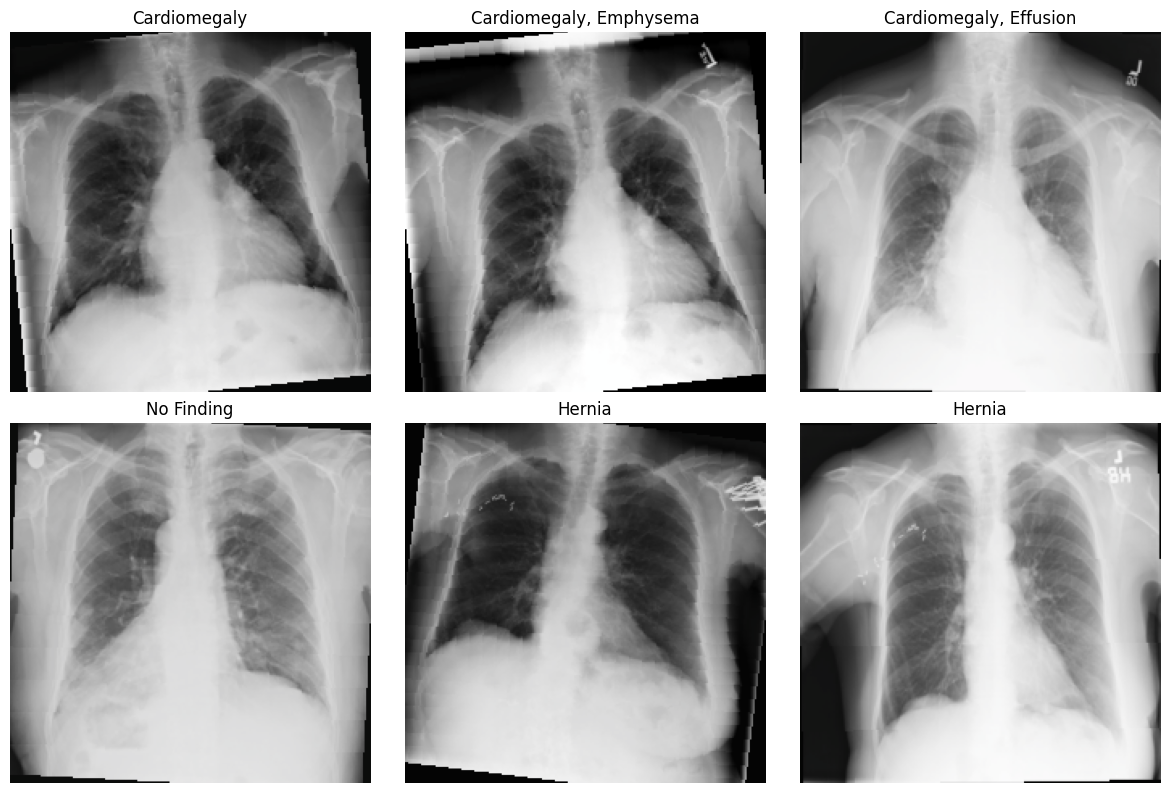

In [6]:
def denormalize(tensor):
    img = tensor.detach().cpu().permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, i in zip(axes.flat, range(6)):
    image, target, path = train_ds[i]
    ax.imshow(denormalize(image))
    labels = [DISEASES[j] for j, v in enumerate(target) if v > 0.5]
    ax.set_title(", ".join(labels[:3]) if labels else "No Finding")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 7. Class weights

In [7]:
positive = train_df[DISEASES].sum().values.astype(np.float32)
negative = len(train_df) - positive
pos_weight = np.clip(negative / np.maximum(positive, 1.0), 1.0, 50.0)
pos_weight = torch.tensor(pos_weight, dtype=torch.float32, device=DEVICE)

display(pd.DataFrame({
    "Disease": DISEASES,
    "Positive": positive.astype(int),
    "Negative": negative.astype(int),
    "pos_weight": pos_weight.cpu().numpy()
}))


,Disease,Positive,Negative,pos_weight
0,Atelectasis,8245,71173,8.632262
1,Cardiomegaly,1915,77503,40.471542
2,Effusion,9484,69934,7.373893
3,Infiltration,14162,65256,4.607824
4,Mass,4110,75308,18.323114
5,Nodule,4524,74894,16.554819
6,Pneumonia,1028,78390,50.000000
7,Pneumothorax,3831,75587,19.730358
8,Consolidation,3332,76086,22.834934
9,Edema,1629,77789,47.752609


## 8. DenseNet-121 baseline

In [8]:
def build_densenet_baseline():
    model = models.densenet121(
        weights=models.DenseNet121_Weights.DEFAULT
    )
    model.classifier = nn.Linear(
        model.classifier.in_features,
        NUM_CLASSES
    )
    return model

baseline = build_densenet_baseline().to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(baseline.classifier)


Linear(in_features=1024, out_features=14, bias=True)


## 9. Evaluation utilities

In [9]:
def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total = 0.0

    for images, targets, _ in tqdm(loader, leave=False):
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = loss_fn(logits, targets)
        loss.backward()
        optimizer.step()

        total += loss.item() * images.size(0)

    return total / len(loader.dataset)


@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    ys, ps = [], []

    for images, targets, _ in tqdm(loader, leave=False):
        images = images.to(DEVICE, non_blocking=True)
        probs = torch.sigmoid(model(images)).cpu().numpy()
        ps.append(probs)
        ys.append(targets.numpy())

    return np.concatenate(ys), np.concatenate(ps)


def per_class_metric(y_true, y_prob, metric):
    values = []
    for i in range(y_true.shape[1]):
        if len(np.unique(y_true[:, i])) < 2:
            values.append(np.nan)
        else:
            values.append(metric(y_true[:, i], y_prob[:, i]))
    return np.asarray(values)


def calculate_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    auroc = per_class_metric(y_true, y_prob, roc_auc_score)
    auprc = per_class_metric(y_true, y_prob, average_precision_score)
    f1 = np.array([
        f1_score(y_true[:, i], y_pred[:, i], zero_division=0)
        for i in range(y_true.shape[1])
    ])

    return {
        "mean_auroc": float(np.nanmean(auroc)),
        "mean_auprc": float(np.nanmean(auprc)),
        "mean_f1": float(np.mean(f1)),
        "auroc_per_disease": auroc,
        "auprc_per_disease": auprc,
        "f1_per_disease": f1,
    }


def print_metrics(metrics, name):
    print(f"\n{name}")
    print("-" * 45)
    print(f"Mean AUROC: {metrics['mean_auroc']:.4f}")
    print(f"Mean AUPRC: {metrics['mean_auprc']:.4f}")
    print(f"Mean F1:    {metrics['mean_f1']:.4f}")


## 10. Train DenseNet baseline

In [10]:
baseline_optimizer = torch.optim.AdamW(
    baseline.parameters(), lr=LR, weight_decay=1e-4
)

baseline_history = []

for epoch in range(1, EPOCHS_BASELINE + 1):
    loss = train_one_epoch(
        baseline, train_loader, baseline_optimizer, criterion
    )

    yv, pv = collect_predictions(baseline, val_loader)
    m = calculate_metrics(yv, pv)

    baseline_history.append({
        "epoch": epoch,
        "loss": loss,
        "val_auroc": m["mean_auroc"],
        "val_auprc": m["mean_auprc"],
        "val_f1": m["mean_f1"],
    })

    print(
        f"Epoch {epoch}/{EPOCHS_BASELINE} | "
        f"loss={loss:.4f} | AUROC={m['mean_auroc']:.4f}"
    )

display(pd.DataFrame(baseline_history))


Epoch 1/10 | loss=0.8978 | AUROC=0.8032


Epoch 2/10 | loss=0.8132 | AUROC=0.8194


Epoch 3/10 | loss=0.7820 | AUROC=0.8197


Epoch 4/10 | loss=0.7568 | AUROC=0.8342


Epoch 5/10 | loss=0.7332 | AUROC=0.8311


...

Epoch 7/10 | loss=0.6824 | AUROC=0.8326


Epoch 8/10 | loss=0.6584 | AUROC=0.8294


Epoch 9/10 | loss=0.6325 | AUROC=0.8289


Epoch 10/10 | loss=0.6060 | AUROC=0.8225


,epoch,loss,val_auroc,val_auprc,val_f1
0,1,0.897832,0.803164,0.195376,0.192772
1,2,0.813161,0.819441,0.235913,0.211402
2,3,0.781992,0.819747,0.235946,0.201369
3,4,0.756775,0.834164,0.248684,0.223337
4,5,0.733176,0.831060,0.248933,0.222094
5,6,0.707733,0.833507,0.249920,0.219331
6,7,0.682416,0.832604,0.253999,0.233645
7,8,0.658373,0.829412,0.248608,0.239253
8,9,0.632530,0.828905,0.254008,0.222370
9,10,0.606023,0.822544,0.249296,0.237794


## 11. Test DenseNet

In [11]:
baseline_true, baseline_prob = collect_predictions(baseline, test_loader)
baseline_metrics = calculate_metrics(baseline_true, baseline_prob)

print_metrics(baseline_metrics, "DenseNet-121 Test")

baseline_disease_table = pd.DataFrame({
    "Disease": DISEASES,
    "AUROC": baseline_metrics["auroc_per_disease"],
    "AUPRC": baseline_metrics["auprc_per_disease"],
    "F1": baseline_metrics["f1_per_disease"],
})
display(baseline_disease_table)



DenseNet-121 Test
---------------------------------------------
Mean AUROC: 0.8258
Mean AUPRC: 0.2546
Mean F1:    0.2443


,Disease,AUROC,AUPRC,F1
0,Atelectasis,0.787602,0.303294,0.326783
1,Cardiomegaly,0.908575,0.276429,0.264680
2,Effusion,0.878658,0.505118,0.447132
3,Infiltration,0.694015,0.321207,0.384683
4,Mass,0.833333,0.294912,0.291181
5,Nodule,0.752760,0.220627,0.217143
6,Pneumonia,0.715308,0.035427,0.071398
7,Pneumothorax,0.852479,0.282870,0.343729
8,Consolidation,0.808719,0.145700,0.196386
9,Edema,0.875892,0.146497,0.176173


# 12. Simple 3-Expert Anatomical MoE

```text
X-ray
  ↓
DenseNet feature extractor
  ↓
1024-d feature vector
  ↓
Router → [Lung, Cardiac, Pleural]
  ↓
3 expert predictions
  ↓
Weighted sum
  ↓
14 disease logits
```

The router is intentionally simple: **3 weights per image**, not disease-specific routing.


In [12]:
class MLPExpert(nn.Module):
    def __init__(self, in_dim, num_classes, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.net(x)


class SimpleAnatomicalMoE(nn.Module):
    def __init__(self, num_classes=14):
        super().__init__()

        backbone = models.densenet121(
            weights=models.DenseNet121_Weights.DEFAULT
        )

        self.features = backbone.features
        self.feature_dim = backbone.classifier.in_features

        self.router = nn.Linear(self.feature_dim, 3)

        self.lung_expert = MLPExpert(self.feature_dim, num_classes)
        self.cardiac_expert = MLPExpert(self.feature_dim, num_classes)
        self.pleural_expert = MLPExpert(self.feature_dim, num_classes)

    def encode(self, x):
        x = self.features(x)
        x = F.relu(x, inplace=False)
        x = F.adaptive_avg_pool2d(x, (1, 1))
        return torch.flatten(x, 1)

    def forward(self, x, return_details=False):
        features = self.encode(x)

        # [B, 3]
        routing = F.softmax(self.router(features), dim=1)

        lung = self.lung_expert(features)
        cardiac = self.cardiac_expert(features)
        pleural = self.pleural_expert(features)

        # [B, 3, 14]
        experts = torch.stack([lung, cardiac, pleural], dim=1)

        # [B, 14]
        final_logits = (
            routing.unsqueeze(-1) * experts
        ).sum(dim=1)

        if return_details:
            return final_logits, routing, experts

        return final_logits


moe = SimpleAnatomicalMoE(NUM_CLASSES).to(DEVICE)
print("3-expert MoE created.")


3-expert MoE created.


## 13. Expert specialization loss

In [13]:
expert_groups = {
    "lung": [DISEASE_TO_IDX[d] for d in LUNG_DISEASES],
    "cardiac": [DISEASE_TO_IDX[d] for d in CARDIAC_DISEASES],
    "pleural": [DISEASE_TO_IDX[d] for d in PLEURAL_DISEASES],
}

def expert_auxiliary_loss(expert_logits, targets):
    # expert_logits: [B, 3, 14]
    specs = [
        (0, expert_groups["lung"]),
        (1, expert_groups["cardiac"]),
        (2, expert_groups["pleural"]),
    ]

    losses = []
    for expert_id, indices in specs:
        logits = expert_logits[:, expert_id, indices]
        y = targets[:, indices]
        losses.append(F.binary_cross_entropy_with_logits(logits, y))

    return sum(losses) / len(losses)


## 14. Train the 3-expert MoE

In [ ]:
moe_optimizer = torch.optim.AdamW(
    moe.parameters(),
    lr=LR,
    weight_decay=1e-4
)

moe_history = []


best_val_auroc = -float("inf")
best_epoch = 0

# Save best model weights in memory
best_moe_state = None


for epoch in range(1, EPOCHS_MOE + 1):

    moe.train()
    running = 0.0

    for images, targets, _ in tqdm(
        train_loader,
        leave=False
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        targets = targets.to(
            DEVICE,
            non_blocking=True
        )

        moe_optimizer.zero_grad(
            set_to_none=True
        )

     

        logits, routing, expert_logits = moe(
            images,
            return_details=True
        )

     

        main_loss = criterion(
            logits,
            targets
        )

        aux_loss = expert_auxiliary_loss(
            expert_logits,
            targets
        )

        loss = main_loss + 0.2 * aux_loss

     

        loss.backward()

        moe_optimizer.step()

        running += loss.item() * images.size(0)



    train_loss = running / len(
        train_loader.dataset
    )



    yv, pv = collect_predictions(
        moe,
        val_loader
    )

    m = calculate_metrics(
        yv,
        pv
    )

    val_auroc = m["mean_auroc"]
    val_auprc = m["mean_auprc"]
    val_f1 = m["mean_f1"]

  

    moe_history.append({
        "epoch": epoch,
        "loss": train_loss,
        "val_auroc": val_auroc,
        "val_auprc": val_auprc,
        "val_f1": val_f1,
    })

   

    if val_auroc > best_val_auroc:

        best_val_auroc = val_auroc
        best_epoch = epoch

        # Keep a copy in memory
        best_moe_state = {
            k: v.detach().cpu().clone()
            for k, v in moe.state_dict().items()
        }

        # Save checkpoint to Kaggle working directory
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": moe.state_dict(),
                "optimizer_state_dict": moe_optimizer.state_dict(),
                "train_loss": train_loss,
                "val_auroc": val_auroc,
                "val_auprc": val_auprc,
                "val_f1": val_f1,
            },
            "best_moe_model.pth"
        )

        status = " BEST"

    else:

        status = ""


    print(
        f"Epoch {epoch}/{EPOCHS_MOE} | "
        f"loss={train_loss:.4f} | "
        f"AUROC={val_auroc:.4f} | "
        f"AUPRC={val_auprc:.4f} | "
        f"F1={val_f1:.4f} | "
        f"{status}"
    )



if best_moe_state is not None:

    moe.load_state_dict(
        best_moe_state
    )

    print()
    print("=" * 60)
    print("BEST MoE MODEL RESTORED")
    print("=" * 60)
    print(f"Best epoch : {best_epoch}")
    print(f"Best AUROC : {best_val_auroc:.4f}")
    print("=" * 60)



moe_df = pd.DataFrame(
    moe_history
)

display(moe_df)

Epoch 1/20 | loss=0.6446 | AUROC=0.8253 | AUPRC=0.2537 | F1=0.2218 |  BEST


Epoch 2/20 | loss=0.6234 | AUROC=0.8265 | AUPRC=0.2541 | F1=0.2555 |  BEST


Epoch 3/20 | loss=0.6026 | AUROC=0.8305 | AUPRC=0.2544 | F1=0.2342 |  BEST


Epoch 4/20 | loss=0.5847 | AUROC=0.8272 | AUPRC=0.2534 | F1=0.2333 | 


Epoch 5/20 | loss=0.5611 | AUROC=0.8222 | AUPRC=0.2453 | F1=0.2347 | 


...

Epoch 9/20 | loss=0.4941 | AUROC=0.8182 | AUPRC=0.2364 | F1=0.2452 | 


Epoch 10/20 | loss=0.4762 | AUROC=0.8115 | AUPRC=0.2317 | F1=0.2469 | 


Epoch 11/20 | loss=0.4652 | AUROC=0.8110 | AUPRC=0.2293 | F1=0.2453 | 


Epoch 12/20 | loss=0.4546 | AUROC=0.8059 | AUPRC=0.2358 | F1=0.2445 | 


KeyboardInterrupt: 

## 15. Test the MoE

In [27]:
moe_true, moe_prob = collect_predictions(moe, test_loader)
moe_metrics = calculate_metrics(moe_true, moe_prob)

print_metrics(moe_metrics, "3-Expert Anatomical MoE Test")

moe_disease_table = pd.DataFrame({
    "Disease": DISEASES,
    "AUROC": moe_metrics["auroc_per_disease"],
    "AUPRC": moe_metrics["auprc_per_disease"],
    "F1": moe_metrics["f1_per_disease"],
})
display(moe_disease_table)



3-Expert Anatomical MoE Test
---------------------------------------------
Mean AUROC: 0.8084
Mean AUPRC: 0.2431
Mean F1:    0.2525


,Disease,AUROC,AUPRC,F1
0,Atelectasis,0.788079,0.309647,0.335681
1,Cardiomegaly,0.894775,0.234437,0.248808
2,Effusion,0.875054,0.501510,0.469630
3,Infiltration,0.689317,0.319723,0.380630
4,Mass,0.810305,0.279729,0.300747
5,Nodule,0.721178,0.191946,0.209921
6,Pneumonia,0.657845,0.023997,0.046606
7,Pneumothorax,0.860148,0.283608,0.343203
8,Consolidation,0.768804,0.131119,0.186224
9,Edema,0.868432,0.128982,0.224412


## 16. DenseNet vs MoE

,Model,AUROC,AUPRC,F1
0,DenseNet-121,0.825792,0.254565,0.244275
1,3-Expert MoE,0.808371,0.243077,0.252490


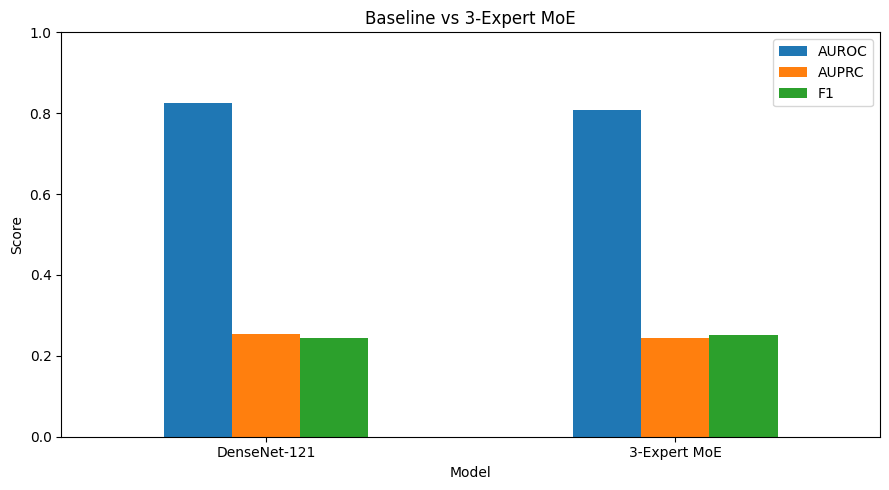

In [28]:
comparison = pd.DataFrame([
    {
        "Model": "DenseNet-121",
        "AUROC": baseline_metrics["mean_auroc"],
        "AUPRC": baseline_metrics["mean_auprc"],
        "F1": baseline_metrics["mean_f1"],
    },
    {
        "Model": "3-Expert MoE",
        "AUROC": moe_metrics["mean_auroc"],
        "AUPRC": moe_metrics["mean_auprc"],
        "F1": moe_metrics["mean_f1"],
    }
])

display(comparison)

comparison.set_index("Model").plot(
    kind="bar", figsize=(9, 5), ylim=(0, 1)
)
plt.ylabel("Score")
plt.title("Baseline vs 3-Expert MoE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 17. Per-disease comparison

,Disease,DenseNet_AUROC,MoE_AUROC,DenseNet_AUPRC,MoE_AUPRC,DenseNet_F1,MoE_F1
0,Atelectasis,0.787602,0.788079,0.303294,0.309647,0.326783,0.335681
1,Cardiomegaly,0.908575,0.894775,0.276429,0.234437,0.264680,0.248808
2,Effusion,0.878658,0.875054,0.505118,0.501510,0.447132,0.469630
3,Infiltration,0.694015,0.689317,0.321207,0.319723,0.384683,0.380630
4,Mass,0.833333,0.810305,0.294912,0.279729,0.291181,0.300747
5,Nodule,0.752760,0.721178,0.220627,0.191946,0.217143,0.209921
6,Pneumonia,0.715308,0.657845,0.035427,0.023997,0.071398,0.046606
7,Pneumothorax,0.852479,0.860148,0.282870,0.283608,0.343729,0.343203
8,Consolidation,0.808719,0.768804,0.145700,0.131119,0.196386,0.186224
9,Edema,0.875892,0.868432,0.146497,0.128982,0.176173,0.224412


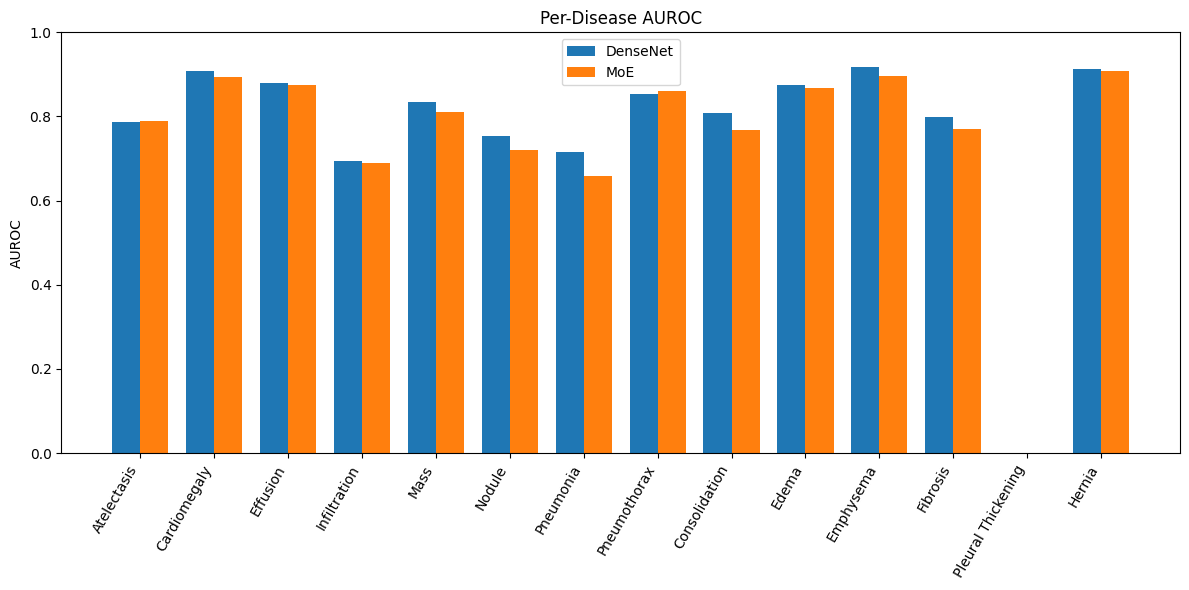

In [29]:
disease_comparison = pd.DataFrame({
    "Disease": DISEASES,
    "DenseNet_AUROC": baseline_metrics["auroc_per_disease"],
    "MoE_AUROC": moe_metrics["auroc_per_disease"],
    "DenseNet_AUPRC": baseline_metrics["auprc_per_disease"],
    "MoE_AUPRC": moe_metrics["auprc_per_disease"],
    "DenseNet_F1": baseline_metrics["f1_per_disease"],
    "MoE_F1": moe_metrics["f1_per_disease"],
})

display(disease_comparison)

x = np.arange(len(DISEASES))
width = 0.38

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, disease_comparison["DenseNet_AUROC"], width, label="DenseNet")
plt.bar(x + width/2, disease_comparison["MoE_AUROC"], width, label="MoE")
plt.xticks(x, DISEASES, rotation=60, ha="right")
plt.ylabel("AUROC")
plt.ylim(0, 1)
plt.title("Per-Disease AUROC")
plt.legend()
plt.tight_layout()
plt.show()


## 18. Expert routing analysis

,Expert,Average Routing Weight
0,Lung,0.226427
1,Cardiac,0.310928
2,Pleural,0.462645


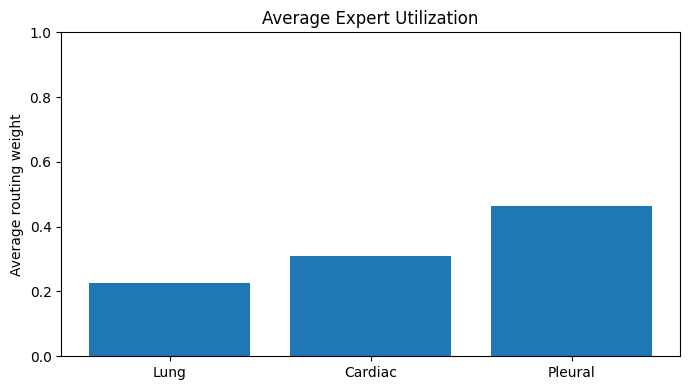

In [30]:
@torch.no_grad()
def collect_routing_weights(model, loader):
    model.eval()
    all_weights = []

    for images, _, _ in tqdm(loader, leave=False):
        images = images.to(DEVICE, non_blocking=True)
        _, weights, _ = model(images, return_details=True)
        all_weights.append(weights.cpu().numpy())

    return np.concatenate(all_weights)

routing_weights = collect_routing_weights(moe, test_loader)
expert_names = ["Lung", "Cardiac", "Pleural"]

routing_df = pd.DataFrame({
    "Expert": expert_names,
    "Average Routing Weight": routing_weights.mean(axis=0)
})

display(routing_df)

plt.figure(figsize=(7, 4))
plt.bar(expert_names, routing_df["Average Routing Weight"])
plt.ylim(0, 1)
plt.ylabel("Average routing weight")
plt.title("Average Expert Utilization")
plt.tight_layout()
plt.show()


## 19. Inspect one MoE prediction

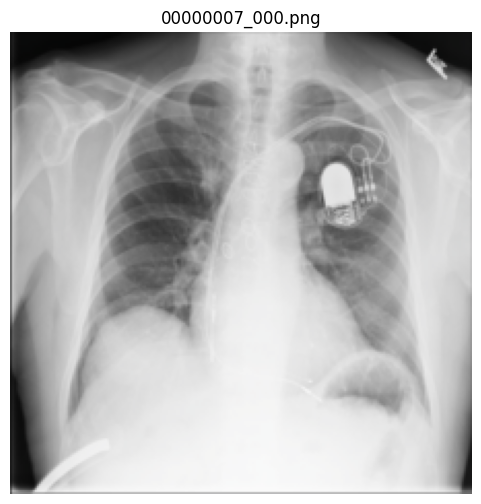

Expert routing:
  Lung      : 0.186
  Cardiac   : 0.251
  Pleural   : 0.563

Top predictions:
  Atelectasis         : 0.608
  Nodule              : 0.533
  Mass                : 0.312
  Cardiomegaly        : 0.244
  Infiltration        : 0.162


In [31]:
@torch.no_grad()
def inspect_moe_sample(model, dataset, index=0):
    image, target, path = dataset[index]

    logits, weights, _ = model(
        image.unsqueeze(0).to(DEVICE),
        return_details=True
    )

    probs = torch.sigmoid(logits[0]).cpu().numpy()
    weights = weights[0].cpu().numpy()

    plt.figure(figsize=(6, 6))
    plt.imshow(denormalize(image))
    plt.axis("off")
    plt.title(Path(path).name)
    plt.show()

    print("Expert routing:")
    for name, w in zip(expert_names, weights):
        print(f"  {name:10s}: {w:.3f}")

    print("\nTop predictions:")
    for idx in np.argsort(probs)[::-1][:5]:
        print(f"  {DISEASES[idx]:20s}: {probs[idx]:.3f}")

inspect_moe_sample(moe, test_ds, 0)


# 20. Grad-CAM

For simplicity, Grad-CAM is demonstrated on the DenseNet baseline.

It answers:

> **Which region of the X-ray influenced the selected prediction?**


In [32]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.fwd = target_layer.register_forward_hook(self.save_activation)
        self.bwd = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, inputs, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, image_tensor, class_idx):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(image_tensor)
        logits[:, class_idx].sum().backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1))

        cam = F.interpolate(
            cam.unsqueeze(1),
            size=(IMAGE_SIZE, IMAGE_SIZE),
            mode="bilinear",
            align_corners=False
        )[0, 0].cpu().numpy()

        cam -= cam.min()
        cam /= cam.max() + 1e-8
        return cam

    def close(self):
        self.fwd.remove()
        self.bwd.remove()

gradcam = GradCAM(
    baseline,
    baseline.features.denseblock4
)


## 21. Show Grad-CAM

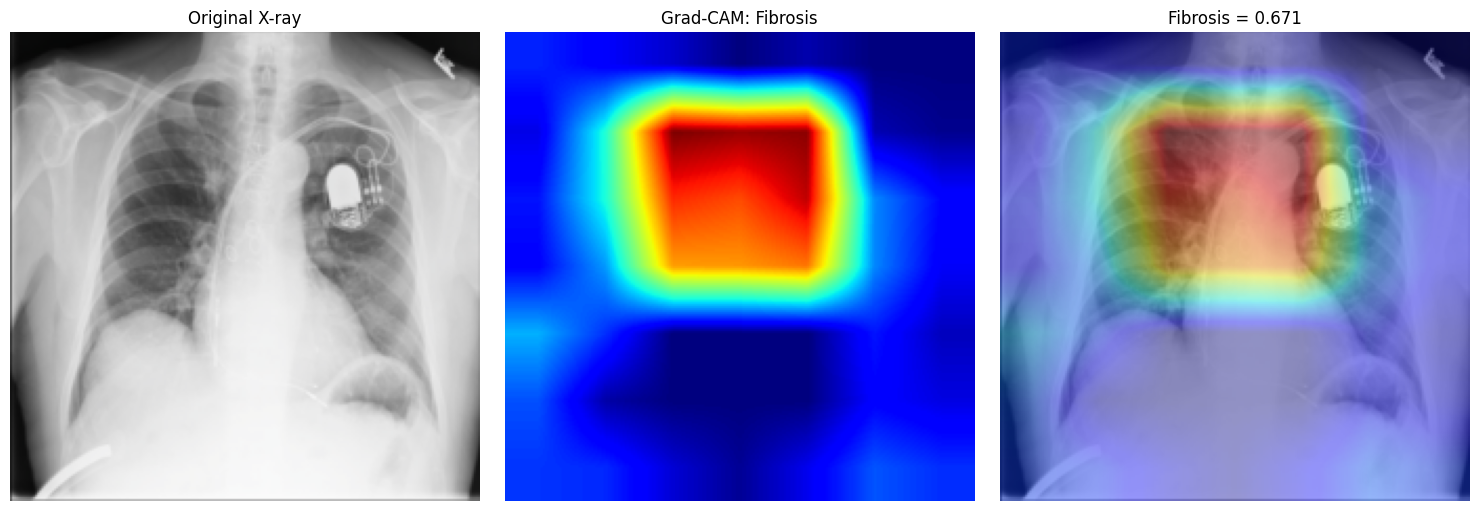

Top 5 predictions:
Fibrosis            : 0.671
Atelectasis         : 0.601
Cardiomegaly        : 0.440
Effusion            : 0.325
Nodule              : 0.185


In [33]:
def show_gradcam(model, dataset, index=0):
    image, target, path = dataset[index]
    x = image.unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(x))[0].cpu().numpy()

    class_idx = int(np.argmax(probs))
    cam = gradcam.generate(x, class_idx)
    original = denormalize(image)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("Original X-ray")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cam, cmap="jet")
    plt.title(f"Grad-CAM: {DISEASES[class_idx]}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(original)
    plt.imshow(cam, cmap="jet", alpha=0.4)
    plt.title(f"{DISEASES[class_idx]} = {probs[class_idx]:.3f}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("Top 5 predictions:")
    for idx in np.argsort(probs)[::-1][:5]:
        print(f"{DISEASES[idx]:20s}: {probs[idx]:.3f}")

show_gradcam(baseline, test_ds, 0)


## 22. Single-image inference

In [34]:
def predict_single(model, image_path, is_moe=False, top_k=5):
    image_path = Path(image_path)
    image = Image.open(image_path).convert("RGB")
    x = eval_transform(image).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        if is_moe:
            logits, routing, _ = model(x, return_details=True)
            routing = routing[0].cpu().numpy()
        else:
            logits = model(x)
            routing = None

        probs = torch.sigmoid(logits[0]).cpu().numpy()

    print("Image:", image_path)
    print("\nTop predictions:")
    for idx in np.argsort(probs)[::-1][:top_k]:
        print(f"{DISEASES[idx]:20s}: {probs[idx]:.3f}")

    if routing is not None:
        print("\nExpert routing:")
        for name, w in zip(expert_names, routing):
            print(f"{name:10s}: {w:.3f}")

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Input X-ray")
    plt.show()

    return probs, routing

# Example:
# example_path = IMAGE_DIR / "00000001_000.png"
# probs, routing = predict_single(moe, example_path, is_moe=True)


## 23. Save models and results

In [35]:
OUTPUT_DIR = DATA_ROOT.parent.parent / "thoraxmoe_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

torch.save(
    baseline.state_dict(),
    OUTPUT_DIR / "densenet121_baseline.pth"
 )
torch.save(
    moe.state_dict(),
    OUTPUT_DIR / "thoraxmoe_3expert.pth"
 )

comparison.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
disease_comparison.to_csv(OUTPUT_DIR / "disease_comparison.csv", index=False)
routing_df.to_csv(OUTPUT_DIR / "expert_routing.csv", index=False)

config = {
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs_baseline": EPOCHS_BASELINE,
    "epochs_moe": EPOCHS_MOE,
    "learning_rate": LR,
    "diseases": DISEASES,
    "experts": expert_names,
}

with open(OUTPUT_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved to:", OUTPUT_DIR)
print([p.name for p in OUTPUT_DIR.iterdir()])

Saved to: /DATA/deeksha/datasets/thoraxmoe_outputs
['expert_routing.csv', 'thoraxmoe_3expert.pth', 'disease_comparison.csv', 'model_comparison.csv', 'densenet121_baseline.pth', 'config.json']
